# PLACEMENT PREDICTION 

# Problem Statement

The objective of this project is to build a Machine Learning model that predicts whether a student will be placed or not based on their academic performance, work experience, and other relevant attributes. The project aims to analyze the factors that influence campus placements by performing Exploratory Data Analysis (EDA), Data Cleaning, Feature Engineering, Feature Scaling, and Model Building.

Multiple machine learning algorithms will be trained and evaluated to identify the best-performing model. The final model will be used to predict the placement status of new students based on their input details.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [7]:
df = pd.read_csv(r'C:\\Users\\Arjun Singh Tomar\\Downloads\\placementproject---1(ml).zip')

In [8]:
df.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [9]:
# EDA (Exploratory Data Analysis)

In [10]:
print("the size of the datasets is ")
df.shape

the size of the datasets is 


(10000, 12)

In [11]:
print("the statics of the datasets is ")
df.describe()

the statics of the datasets is 


,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,7.698010,1.049200,2.026600,1.013200,79.449900,4.323960,69.159400,74.501500
std,2886.89568,0.640131,0.665901,0.867968,0.904272,8.159997,0.411622,10.430459,8.919527
min,1.00000,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,55.000000,57.000000
25%,2500.75000,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,59.000000,67.000000
50%,5000.50000,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,70.000000,73.000000
75%,7500.25000,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,78.000000,83.000000
max,10000.00000,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,90.000000,88.000000


In [12]:
print("how many numnber of the missing value are there in")
df.isnull().sum()

how many numnber of the missing value are there in


StudentID                    0
CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64

In [13]:
print("the information of the datasets")
df.info()

the information of the datasets
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  object 
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB


In [14]:
print("check the duplicate value ")
df.duplicated().sum()

check the duplicate value 


np.int64(0)

In [15]:
print("the last features of the datasets")
df.tail()

the last features of the datasets


,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
9995,9996,7.5,1,1,2,72,3.9,Yes,No,85,66,NotPlaced
9996,9997,7.4,0,1,0,90,4.8,No,No,84,67,Placed
9997,9998,8.4,1,3,0,70,4.8,Yes,Yes,79,81,Placed
9998,9999,8.9,0,3,2,87,4.8,Yes,Yes,71,85,Placed
9999,10000,8.4,0,1,1,66,3.8,No,No,62,66,NotPlaced


In [16]:
print("how many columns are there in")
df.columns

how many columns are there in


Index(['StudentID', 'CGPA', 'Internships', 'Projects',
       'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating',
       'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks',
       'HSC_Marks', 'PlacementStatus'],
      dtype='object')

In [17]:
print("the datatypes of the features ")
df.dtypes

the datatypes of the features 


StudentID                      int64
CGPA                         float64
Internships                    int64
Projects                       int64
Workshops/Certifications       int64
AptitudeTestScore              int64
SoftSkillsRating             float64
ExtracurricularActivities     object
PlacementTraining             object
SSC_Marks                      int64
HSC_Marks                      int64
PlacementStatus               object
dtype: object

In [18]:
print("the randomly choosen features")
df.sample(5)

the randomly choosen features


,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
2327,2328,7.8,1,3,0,90,4.6,No,Yes,64,83,NotPlaced
3326,3327,6.8,1,1,1,72,4.8,No,Yes,62,67,NotPlaced
4767,4768,7.8,1,3,2,82,4.8,Yes,No,78,77,Placed
6804,6805,7.3,1,1,1,71,3.8,No,Yes,57,57,NotPlaced
1915,1916,8.3,2,3,2,87,4.6,Yes,Yes,78,82,Placed


In [19]:
print("the correlation of the datasets is ")
df.corr(numeric_only = True)

the correlation of the datasets is 


,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks
StudentID,1.000000,0.005724,0.015655,0.015924,0.011872,0.020314,-0.002269,-0.003082,0.024115
CGPA,0.005724,1.000000,0.280601,0.435928,0.349686,0.461250,0.383547,0.404971,0.462313
Internships,0.015655,0.280601,1.000000,0.309196,0.279110,0.320725,0.273691,0.279837,0.317149
Projects,0.015924,0.435928,0.309196,1.000000,0.377865,0.540339,0.450294,0.499421,0.535708
Workshops/Certifications,0.011872,0.349686,0.279110,0.377865,1.000000,0.388061,0.342397,0.373045,0.418442
AptitudeTestScore,0.020314,0.461250,0.320725,0.540339,0.388061,1.000000,0.515400,0.513044,0.565105
SoftSkillsRating,-0.002269,0.383547,0.273691,0.450294,0.342397,0.515400,1.000000,0.430734,0.466912
SSC_Marks,-0.003082,0.404971,0.279837,0.499421,0.373045,0.513044,0.430734,1.000000,0.524916
HSC_Marks,0.024115,0.462313,0.317149,0.535708,0.418442,0.565105,0.466912,0.524916,1.000000


<Axes: >

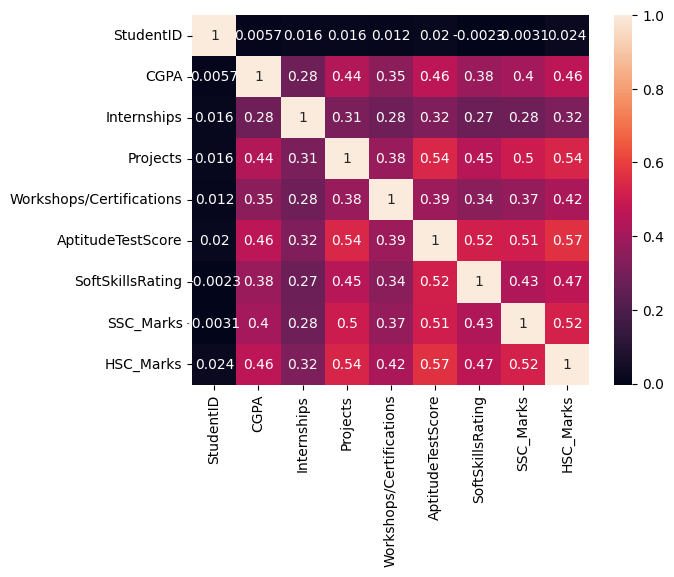

In [20]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

the outliers are 


<Axes: xlabel='Projects'>

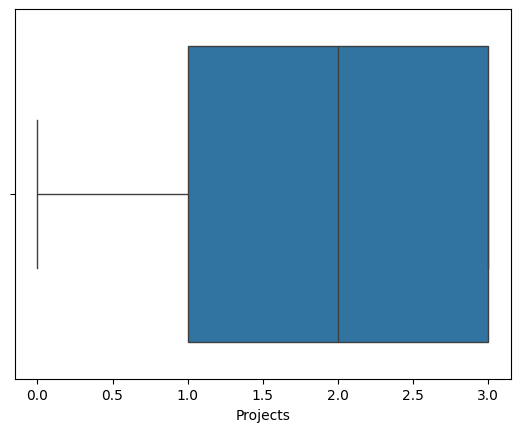

In [21]:
print("the outliers are ")
sns.boxplot(x=df["Projects"])

In [22]:
print("categorical column analysis")
df["ExtracurricularActivities"].value_counts()

categorical column analysis


ExtracurricularActivities
Yes    5854
No     4146
Name: count, dtype: int64

<Axes: xlabel='ExtracurricularActivities', ylabel='count'>

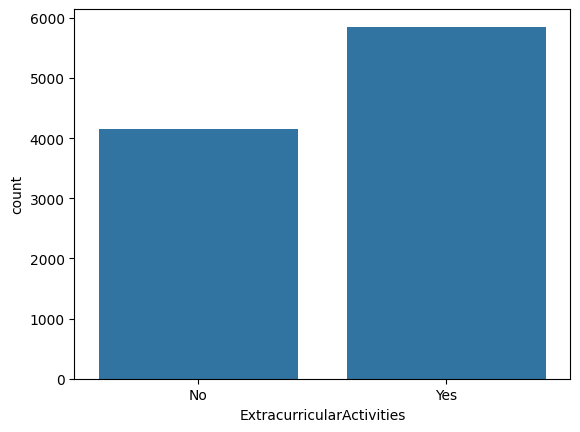

In [23]:
sns.countplot(x="ExtracurricularActivities",data=df)

In [24]:
print("catagorical column analysis")
df["PlacementStatus"].value_counts()

catagorical column analysis


PlacementStatus
NotPlaced    5803
Placed       4197
Name: count, dtype: int64

<Axes: xlabel='PlacementStatus', ylabel='count'>

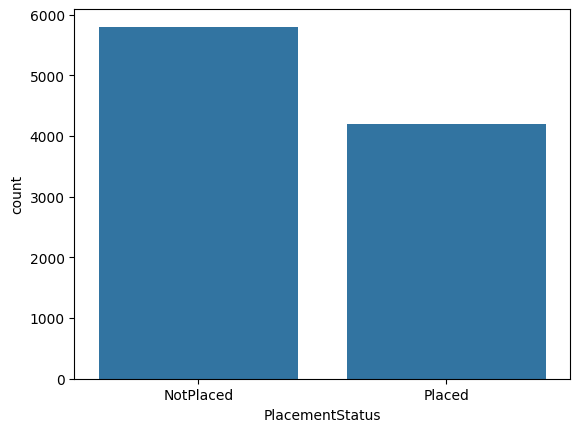

In [25]:
sns.countplot(x="PlacementStatus",data=df)

bivariate eda (numerical vs categoriacal)


<Axes: xlabel='PlacementStatus', ylabel='CGPA'>

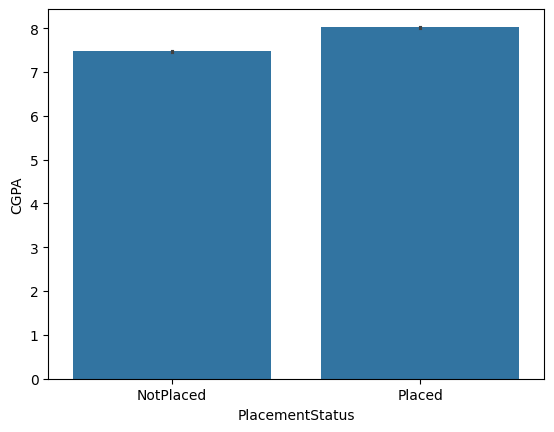

In [26]:
print("bivariate eda (numerical vs categoriacal)")
sns.barplot(x="PlacementStatus", y="CGPA", data=df)

numerical vs numerical


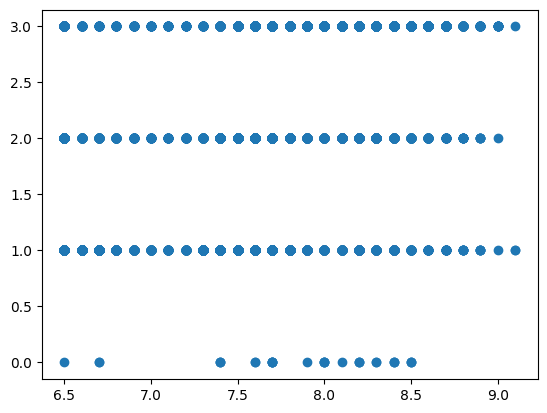

In [27]:
print("numerical vs numerical")
plt.scatter(df["CGPA"],df["Projects"])

categorical vs categorical


<Axes: xlabel='PlacementTraining', ylabel='PlacementStatus'>

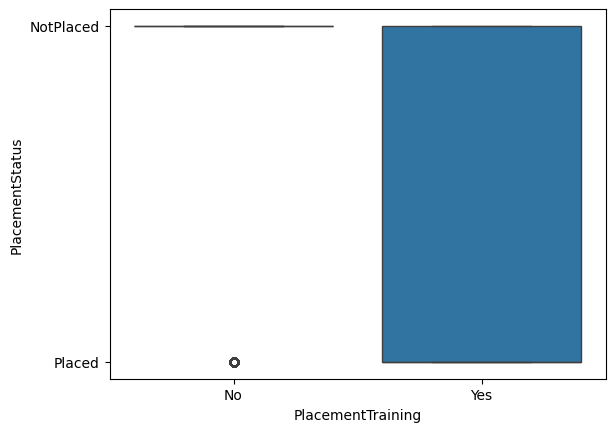

In [28]:
print("categorical vs categorical")
sns.boxplot(x="PlacementTraining",y="PlacementStatus",data=df)

In [29]:
# Feature Engineering 

In [30]:
# Encodinng 
df = pd.get_dummies(df,columns=["ExtracurricularActivities"],dtype=int)
df = pd.get_dummies(df,columns=["PlacementTraining"],dtype=int)
df["PlacementStatus"] = df["PlacementStatus"].map({
    "Placed": 1,
    "NotPlaced": 0
})

In [31]:
df.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks,PlacementStatus,ExtracurricularActivities_No,ExtracurricularActivities_Yes,PlacementTraining_No,PlacementTraining_Yes
0,1,7.5,1,1,1,65,4.4,61,79,0,1,0,1,0
1,2,8.9,0,3,2,90,4.0,78,82,1,0,1,0,1
2,3,7.3,1,2,2,82,4.8,79,80,0,0,1,1,0
3,4,7.5,1,1,2,85,4.4,81,80,1,0,1,0,1
4,5,8.3,1,2,2,86,4.5,74,88,1,0,1,0,1


In [32]:
# Spliting X and Y 
X = df.drop(columns=("PlacementStatus"),axis=1)
y = df['PlacementStatus']

In [33]:
# train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42
)

In [34]:
print("the size of Xtrain and Xtest is ")
X_train.shape , X_test.shape

the size of Xtrain and Xtest is 


((6700, 13), (3300, 13))

In [35]:
num_cols = [
    'CGPA',
    'Internships',
    'Projects',
    'Workshops/Certifications',
    'AptitudeTestScore',
    'SoftSkillsRating',
    'SSC_Marks',
    'HSC_Marks'
]

In [36]:

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [37]:
X_train[num_cols].head()

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks
8371,0.943987,1.437236,1.126258,1.085415,1.294368,-0.058352,0.561962,0.838664
5027,0.631045,-0.068782,-1.174680,-0.016446,-0.665079,0.427916,0.083873,-1.405769
9234,-1.872489,-1.574801,-0.024211,-0.016446,-2.379594,-2.975960,-0.872307,-0.844660
3944,0.005161,-0.068782,-1.174680,1.085415,-0.052752,-0.544620,-0.776689,1.063107
6862,-1.716019,1.437236,1.126258,1.085415,0.682041,1.157318,0.944434,1.175329


In [38]:
# logistic algorithm 
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression( max_iter=1000,
    random_state=42)

In [39]:
classifier.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [40]:
y_pred = classifier.predict(X_test)
y_proba = classifier.predict_proba(X_test)[:,1]

In [41]:
y_pred
y_proba

array([0.05671891, 0.14863945, 0.00969156, ..., 0.72093715, 0.22339597,
       0.30402506], shape=(3300,))

In [42]:
from sklearn.metrics import accuracy_score,classification_report

In [43]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


In [44]:
print("accuracy is ",accuracy_score(y_test,y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC :", roc_auc_score(y_test, y_proba))


accuracy is  0.7909090909090909
Precision : 0.7436079545454546
Recall : 0.7609011627906976
F1 Score : 0.7521551724137931
ROC AUC : 0.8714369137697625


classification report is                precision    recall  f1-score   support

           0       0.83      0.81      0.82      1924
           1       0.74      0.76      0.75      1376

    accuracy                           0.79      3300
   macro avg       0.78      0.79      0.79      3300
weighted avg       0.79      0.79      0.79      3300

[[1563  361]
 [ 329 1047]]


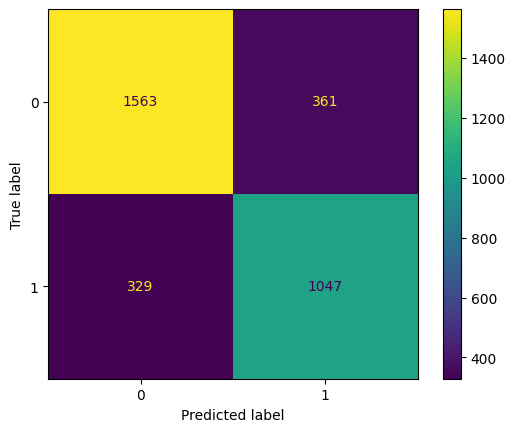

In [45]:
print("classification report is ",classification_report(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred)
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()


In [46]:
# knn algorithm 
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

In [47]:
knn.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [48]:
y_pred_knn = knn.predict(X_test)
y_proba_knn = knn.predict_proba(X_test)[:,1]

In [49]:
y_pred_knn

array([0, 1, 0, ..., 1, 0, 0], shape=(3300,))

accuracy is 0.6127272727272727
Precision : 0.5413851351351351
Recall : 0.46584302325581395
F1 Score : 0.50078125
ROC AUC : 0.6230626450466568
classification report is                precision    recall  f1-score   support

           0       0.65      0.72      0.68      1924
           1       0.54      0.47      0.50      1376

    accuracy                           0.61      3300
   macro avg       0.60      0.59      0.59      3300
weighted avg       0.61      0.61      0.61      3300

[[1381  543]
 [ 735  641]]


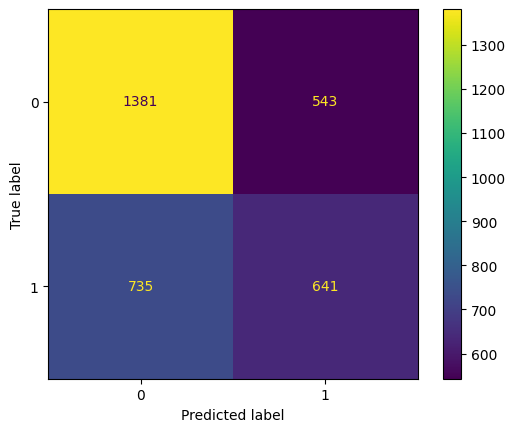

In [50]:
print("accuracy is",accuracy_score(y_test,y_pred_knn))
print("Precision :", precision_score(y_test, y_pred_knn))
print("Recall :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))
print("ROC AUC :", roc_auc_score(y_test, y_proba_knn))
print("classification report is ",classification_report(y_test,y_pred_knn))
cm = confusion_matrix(y_test, y_pred_knn)
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()


In [51]:
# decision tree 
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)

In [52]:
dt.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [53]:
y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:,1]

In [54]:
y_pred_dt

array([0, 1, 0, ..., 1, 0, 0], shape=(3300,))

accuracy is  0.7103030303030303
accuracy is 0.7103030303030303
Precision : 0.6468531468531469
Recall : 0.6722383720930233
F1 Score : 0.6593014967925873
ROC AUC : 0.7048821798095054
classification report is                precision    recall  f1-score   support

           0       0.76      0.74      0.75      1924
           1       0.65      0.67      0.66      1376

    accuracy                           0.71      3300
   macro avg       0.70      0.70      0.70      3300
weighted avg       0.71      0.71      0.71      3300

[[1419  505]
 [ 451  925]]


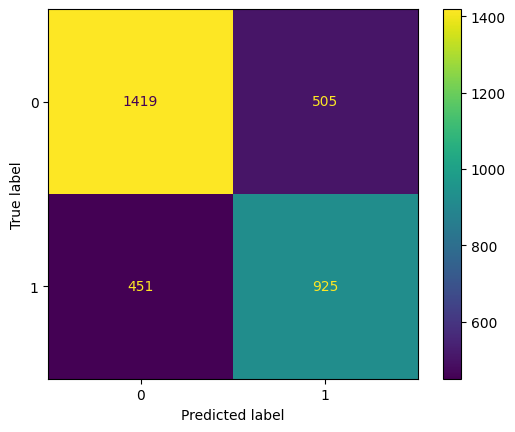

In [55]:
print("accuracy is ",accuracy_score(y_test,y_pred_dt))
print("accuracy is",accuracy_score(y_test,y_pred_dt))
print("Precision :", precision_score(y_test, y_pred_dt))
print("Recall :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC AUC :", roc_auc_score(y_test, y_proba_dt))
print("classification report is ",classification_report(y_test,y_pred_dt))
cm = confusion_matrix(y_test, y_pred_dt)
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

In [56]:
# random forest 
from sklearn.ensemble import RandomForestClassifier
rdt = RandomForestClassifier()

In [57]:
rdt.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [58]:
y_pred_rdt = rdt.predict(X_test)
y_proba_rdt = rdt.predict_proba(X_test)[:,1]

In [59]:
y_pred_rdt

array([0, 0, 0, ..., 1, 0, 0], shape=(3300,))

accuracy 0.7793939393939394
accuracy is 0.7793939393939394
Precision : 0.7462006079027356
Recall : 0.7136627906976745
F1 Score : 0.7295690936106983
ROC AUC : 0.8628406330077841
classification report is                precision    recall  f1-score   support

           0       0.80      0.83      0.81      1924
           1       0.75      0.71      0.73      1376

    accuracy                           0.78      3300
   macro avg       0.77      0.77      0.77      3300
weighted avg       0.78      0.78      0.78      3300

[[1590  334]
 [ 394  982]]


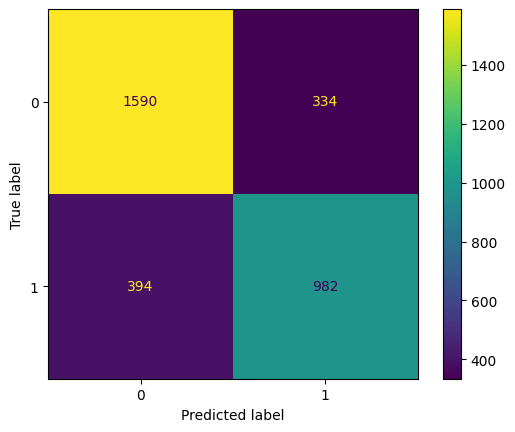

In [60]:
print("accuracy",accuracy_score(y_test,y_pred_rdt))
print("accuracy is",accuracy_score(y_test,y_pred_rdt))
print("Precision :", precision_score(y_test, y_pred_rdt))
print("Recall :", recall_score(y_test, y_pred_rdt))
print("F1 Score :", f1_score(y_test, y_pred_rdt))
print("ROC AUC :", roc_auc_score(y_test, y_proba_rdt))
print("classification report is ",classification_report(y_test,y_pred_rdt))
cm = confusion_matrix(y_test, y_pred_rdt)
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

In [61]:
#svm
from sklearn.svm import SVC
svm = SVC(probability = True,random_state=42)

In [62]:
svm.fit(X_train,y_train)

,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [63]:
y_pred_svm = svm.predict(X_test)
y_proba_svm = svm.predict_proba(X_test)[:,1]

In [64]:
y_pred_svm

array([0, 0, 0, ..., 0, 0, 0], shape=(3300,))

accuracy is  0.583030303030303
accuracy is 0.583030303030303
Precision : 0.0
Recall : 0.0
F1 Score : 0.0
ROC AUC : 0.8429190035294687
classification report is                precision    recall  f1-score   support

           0       0.58      1.00      0.74      1924
           1       0.00      0.00      0.00      1376

    accuracy                           0.58      3300
   macro avg       0.29      0.50      0.37      3300
weighted avg       0.34      0.58      0.43      3300

[[1924    0]
 [1376    0]]


C:\Users\Arjun Singh Tomar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Arjun Singh Tomar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Arjun Singh Tomar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


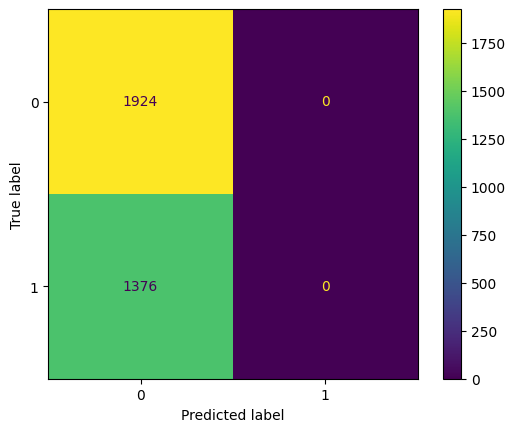

In [65]:
print("accuracy is ",accuracy_score(y_test,y_pred_svm))
print("accuracy is",accuracy_score(y_test,y_pred_svm))
print("Precision :", precision_score(y_test, y_pred_svm))
print("Recall :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))
print("ROC AUC :", roc_auc_score(y_test, y_proba_svm))
print("classification report is ",classification_report(y_test,y_pred_svm))
cm = confusion_matrix(y_test, y_pred_svm)
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

In [66]:
# xgboost
from xgboost import XGBClassifier
xgb = XGBClassifier()

C:\Users\Arjun Singh Tomar\anaconda3\Lib\site-packages\xgboost\compat.py:105: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [67]:
xgb.fit(X_train,y_train)

,base_score,0.5
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,1
,colsample_bynode,1
,colsample_bytree,1
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,gamma,0
,gpu_id,-1


In [68]:
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:,1]
y_pred_xgb

array([0, 0, 0, ..., 0, 0, 0], shape=(3300,))

accuracy score is  0.7727272727272727
accuracy is 0.7727272727272727
Precision : 0.7367624810892587
Recall : 0.7078488372093024
F1 Score : 0.7220163083765753
ROC AUC : 0.8473863650099116
classification report is                precision    recall  f1-score   support

           0       0.80      0.82      0.81      1924
           1       0.74      0.71      0.72      1376

    accuracy                           0.77      3300
   macro avg       0.77      0.76      0.76      3300
weighted avg       0.77      0.77      0.77      3300

[[1576  348]
 [ 402  974]]


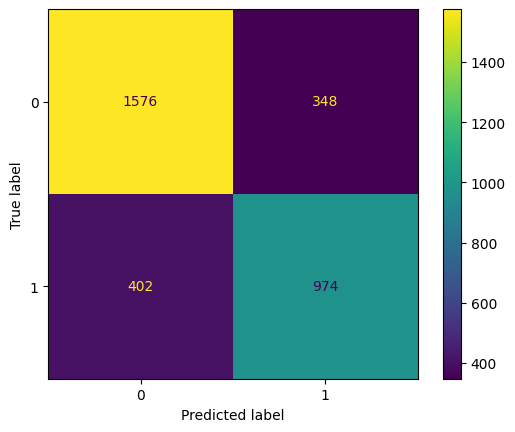

In [69]:
print("accuracy score is ",accuracy_score(y_test,y_pred_xgb))
print("accuracy is",accuracy_score(y_test,y_pred_xgb))
print("Precision :", precision_score(y_test, y_pred_xgb))
print("Recall :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC AUC :", roc_auc_score(y_test, y_proba_xgb))
print("classification report is ",classification_report(y_test,y_pred_xgb))
cm = confusion_matrix(y_test, y_pred_xgb)
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

In [70]:
# lightbm algorithm
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(random_state=42)

In [71]:
lgbm.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 2821, number of negative: 3879
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000868 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 427
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.421045 -> initscore=-0.318486
[LightGBM] [Info] Start training from score -0.318486


,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [72]:
y_pred_lgbm = lgbm.predict(X_test)
y_proba_lgbm = lgbm.predict_proba(X_test)[:,1]

In [73]:
y_pred_lgbm

array([0, 0, 0, ..., 1, 0, 0], shape=(3300,))

accuracy score is 0.7812121212121212
accuracy is 0.7812121212121212
Precision : 0.7429420505200595
Recall : 0.7267441860465116
F1 Score : 0.7347538574577517
ROC AUC : 0.861654574408935
classification report is                precision    recall  f1-score   support

           0       0.81      0.82      0.81      1924
           1       0.74      0.73      0.73      1376

    accuracy                           0.78      3300
   macro avg       0.78      0.77      0.77      3300
weighted avg       0.78      0.78      0.78      3300

[[1578  346]
 [ 376 1000]]


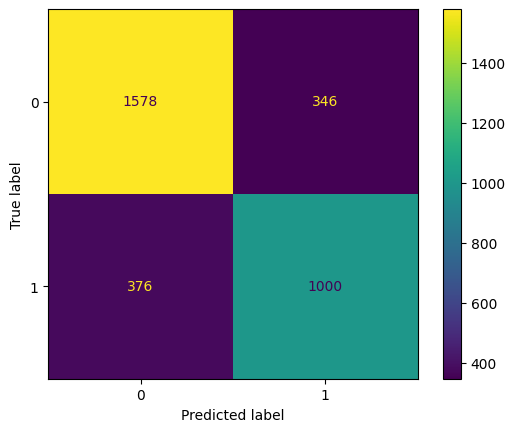

In [74]:
print("accuracy score is",accuracy_score(y_test,y_pred_lgbm))
print("accuracy is",accuracy_score(y_test,y_pred_lgbm))
print("Precision :", precision_score(y_test, y_pred_lgbm))
print("Recall :", recall_score(y_test, y_pred_lgbm))
print("F1 Score :", f1_score(y_test, y_pred_lgbm))
print("ROC AUC :", roc_auc_score(y_test, y_proba_lgbm))
print("classification report is ",classification_report(y_test,y_pred_lgbm))
cm = confusion_matrix(y_test, y_pred_lgbm)
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

In [75]:
# catboost 
from catboost import CatBoostClassifier
cat = CatBoostClassifier(verbose=0,random_state=42) 

In [76]:
cat.fit(X_train,y_train)

CatBoostClassifier(random_state=42, verbose=0)

In [77]:
y_pred_cat = cat.predict(X_test)
y_proba_cat = cat.predict_proba(X_test)[:,1]

In [78]:
y_pred_cat

array([0, 0, 0, ..., 1, 0, 0], shape=(3300,))

accuracy score is  0.7812121212121212
accuracy is 0.7812121212121212
Precision : 0.7451274362818591
Recall : 0.7223837209302325
F1 Score : 0.7335793357933579
ROC AUC : 0.866923469757772
classification report is                precision    recall  f1-score   support

           0       0.81      0.82      0.81      1924
           1       0.75      0.72      0.73      1376

    accuracy                           0.78      3300
   macro avg       0.78      0.77      0.77      3300
weighted avg       0.78      0.78      0.78      3300

[[1584  340]
 [ 382  994]]


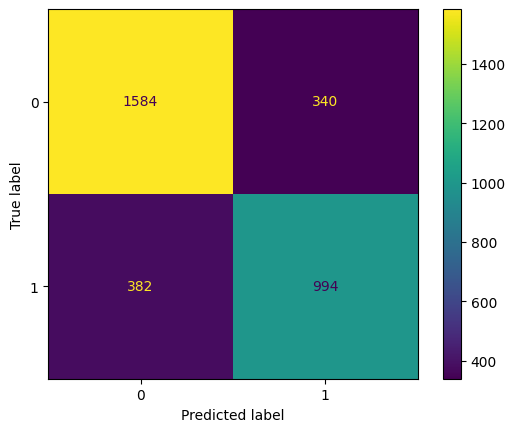

In [79]:
print("accuracy score is ",accuracy_score(y_test,y_pred_cat))
print("accuracy is",accuracy_score(y_test,y_pred_cat))
print("Precision :", precision_score(y_test, y_pred_cat))
print("Recall :", recall_score(y_test, y_pred_cat))
print("F1 Score :", f1_score(y_test, y_pred_cat))
print("ROC AUC :", roc_auc_score(y_test, y_proba_cat))
print("classification report is ",classification_report(y_test,y_pred_cat))
cm = confusion_matrix(y_test, y_pred_cat)
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

In [80]:
results=[]

In [81]:
results.append([
    "Logistic Regression",
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred),
    roc_auc_score(y_test, y_proba)
])

In [82]:
results.append([
    "KNNClassifier",
    accuracy_score(y_test, y_pred_knn),
    precision_score(y_test, y_pred_knn),
    recall_score(y_test, y_pred_knn),
    f1_score(y_test, y_pred_knn),
    roc_auc_score(y_test, y_proba_knn)
])

In [83]:
results.append([
    "Decision tree ",
    accuracy_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_dt),
    roc_auc_score(y_test, y_proba_dt)
])

In [84]:
results.append([
    "random forest",
    accuracy_score(y_test, y_pred_rdt),
    precision_score(y_test, y_pred_rdt),
    recall_score(y_test, y_pred_rdt),
    f1_score(y_test, y_pred_rdt),
    roc_auc_score(y_test, y_proba_rdt)
])

In [85]:
results.append([
    "svm",
    accuracy_score(y_test, y_pred_svm),
    precision_score(y_test, y_pred_svm),
    recall_score(y_test, y_pred_svm),
    f1_score(y_test, y_pred_svm),
    roc_auc_score(y_test, y_proba_svm)
])

C:\Users\Arjun Singh Tomar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [86]:
results.append([
    "XGBoost",
    accuracy_score(y_test, y_pred_xgb),
    precision_score(y_test, y_pred_xgb),
    recall_score(y_test, y_pred_xgb),
    f1_score(y_test, y_pred_xgb),
    roc_auc_score(y_test, y_proba_xgb)
])

In [87]:
results.append([
    "LigthGBM",
    accuracy_score(y_test, y_pred_lgbm),
    precision_score(y_test, y_pred_lgbm),
    recall_score(y_test, y_pred_lgbm),
    f1_score(y_test, y_pred_lgbm),
    roc_auc_score(y_test, y_proba_lgbm)
])

In [88]:
results.append([
    "Catboost", 
    accuracy_score(y_test, y_pred_cat),
    precision_score(y_test, y_pred_cat),
    recall_score(y_test, y_pred_cat),
    f1_score(y_test, y_pred_cat),
    roc_auc_score(y_test, y_proba_cat)
])

In [89]:
comparison = pd.DataFrame(
   results,
    columns = [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

In [90]:
comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.790909,0.743608,0.760901,0.752155,0.871437
1,KNNClassifier,0.612727,0.541385,0.465843,0.500781,0.623063
2,Decision tree,0.710303,0.646853,0.672238,0.659301,0.704882
3,random forest,0.779394,0.746201,0.713663,0.729569,0.862841
4,svm,0.583030,0.000000,0.000000,0.000000,0.842919
5,XGBoost,0.772727,0.736762,0.707849,0.722016,0.847386
6,LigthGBM,0.781212,0.742942,0.726744,0.734754,0.861655
7,Catboost,0.781212,0.745127,0.722384,0.733579,0.866923


In [91]:
comparison.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.790909,0.743608,0.760901,0.752155,0.871437
6,LigthGBM,0.781212,0.742942,0.726744,0.734754,0.861655
7,Catboost,0.781212,0.745127,0.722384,0.733579,0.866923
3,random forest,0.779394,0.746201,0.713663,0.729569,0.862841
5,XGBoost,0.772727,0.736762,0.707849,0.722016,0.847386
2,Decision tree,0.710303,0.646853,0.672238,0.659301,0.704882
1,KNNClassifier,0.612727,0.541385,0.465843,0.500781,0.623063
4,svm,0.583030,0.000000,0.000000,0.000000,0.842919


In [92]:
comparison.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.790909,0.743608,0.760901,0.752155,0.871437
7,Catboost,0.781212,0.745127,0.722384,0.733579,0.866923
3,random forest,0.779394,0.746201,0.713663,0.729569,0.862841
6,LigthGBM,0.781212,0.742942,0.726744,0.734754,0.861655
5,XGBoost,0.772727,0.736762,0.707849,0.722016,0.847386
4,svm,0.583030,0.000000,0.000000,0.000000,0.842919
2,Decision tree,0.710303,0.646853,0.672238,0.659301,0.704882
1,KNNClassifier,0.612727,0.541385,0.465843,0.500781,0.623063


In [93]:
comparison = comparison.round(3)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.791,0.744,0.761,0.752,0.871
1,KNNClassifier,0.613,0.541,0.466,0.501,0.623
2,Decision tree,0.710,0.647,0.672,0.659,0.705
3,random forest,0.779,0.746,0.714,0.730,0.863
4,svm,0.583,0.000,0.000,0.000,0.843
5,XGBoost,0.773,0.737,0.708,0.722,0.847
6,LigthGBM,0.781,0.743,0.727,0.735,0.862
7,Catboost,0.781,0.745,0.722,0.734,0.867


In [94]:
best_model = comparison.sort_values(by="ROC-AUC", ascending=False)
best_model.head(1)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.791,0.744,0.761,0.752,0.871


### Model Comparison Conclusion

- Total 8 classification algorithms were trained and evaluated.
- The models were compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
- Based on the evaluation metrics, **LOGISTIC REGRESSION** achieved the best overall performance.
- Therefore, this model will be selected for hyperparameter tuning and deployment.

In [95]:
# HYPERPARAMETER TUNNING 
from sklearn.model_selection import GridSearchCV

In [96]:
parameter = [
    {
        'solver': ['lbfgs'],
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10],
        'max_iter': [1000]
    },
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 10],
        'max_iter': [1000]
    }
]

In [97]:
classifier_reg = GridSearchCV(classifier,param_grid=parameter,scoring='accuracy',cv=5)

In [98]:
import sklearn
print(sklearn.__version__)

1.9.0


In [99]:
classifier_reg.fit(X_train,y_train)

C:\Users\Arjun Singh Tomar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\Arjun Singh Tomar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\Arjun Singh Tomar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\Arjun Singh Tomar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\Arjun Singh Tomar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserW

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.01, 0.1, ...], 'max_iter': [1000], 'penalty': ['l2'], 'solver': ['lbfgs']}, {'C': [0.01, 0.1, ...], 'max_iter': [1000], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score...

In [100]:
classifier_reg.best_params_

{'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}

In [101]:
classifier_reg.best_score_

np.float64(0.8061194029850747)

In [107]:
import joblib

joblib.dump(classifier, "placement_model.joblib")
joblib.dump(scaler, "scalerp.joblib")

['scalerp.joblib']

In [108]:
X_train.columns

Index(['StudentID', 'CGPA', 'Internships', 'Projects',
       'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating',
       'SSC_Marks', 'HSC_Marks', 'ExtracurricularActivities_No',
       'ExtracurricularActivities_Yes', 'PlacementTraining_No',
       'PlacementTraining_Yes'],
      dtype='object')

In [109]:
# prediction(check the model)
sample = pd.DataFrame({
    'StudentID' :[1], 'CGPA' : [9.2] , 'Internships' : [3], 'Projects' : [2],
       'Workshops/Certifications' : [2], 'AptitudeTestScore' : [86], 'SoftSkillsRating' :[4.0],
       'SSC_Marks':[78], 'HSC_Marks':[82], 'ExtracurricularActivities_No':[1],
       'ExtracurricularActivities_Yes':[0], 'PlacementTraining_No':[1],
       'PlacementTraining_Yes':[0]
})

In [110]:
import joblib

loaded_model = joblib.load("placement_model.joblib")

In [111]:
loaded_scaler = joblib.load("scalerp.joblib")

In [112]:
sample[num_cols] = loaded_scaler.transform(sample[num_cols])
prediction = loaded_model.predict(sample)

print(prediction)
if(prediction == 0 ):
    print("Not Placed")
else:
    print("Placed")

[0]
Not Placed


In [113]:
import os
print(os.getcwd())

C:\Users\Arjun Singh Tomar\anaconda_projects


In [114]:
import os
print(os.path.exists("placement_model.joblib"))

True


In [115]:
import shutil

shutil.copy2(
    "placement_model.joblib",
    r"C:\Users\Arjun Singh Tomar\OneDrive\Desktop\Streamlit\chai-streamlit\placement_model.joblib"
)

print("Copied successfully!")

Copied successfully!


In [116]:
import shutil

shutil.copy2(
    "scalerp.joblib",
    r"C:\Users\Arjun Singh Tomar\OneDrive\Desktop\Streamlit\chai-streamlit\scaler.joblib"
)

print("Scaler copied successfully!")

Scaler copied successfully!
